In [1]:
import numpy as np
x = np.linspace(400, 800, 100)
yerr = 1.0
y = np.random.normal(20 * np.exp(-0.5 * ((x-500)/4.2)**2), yerr)

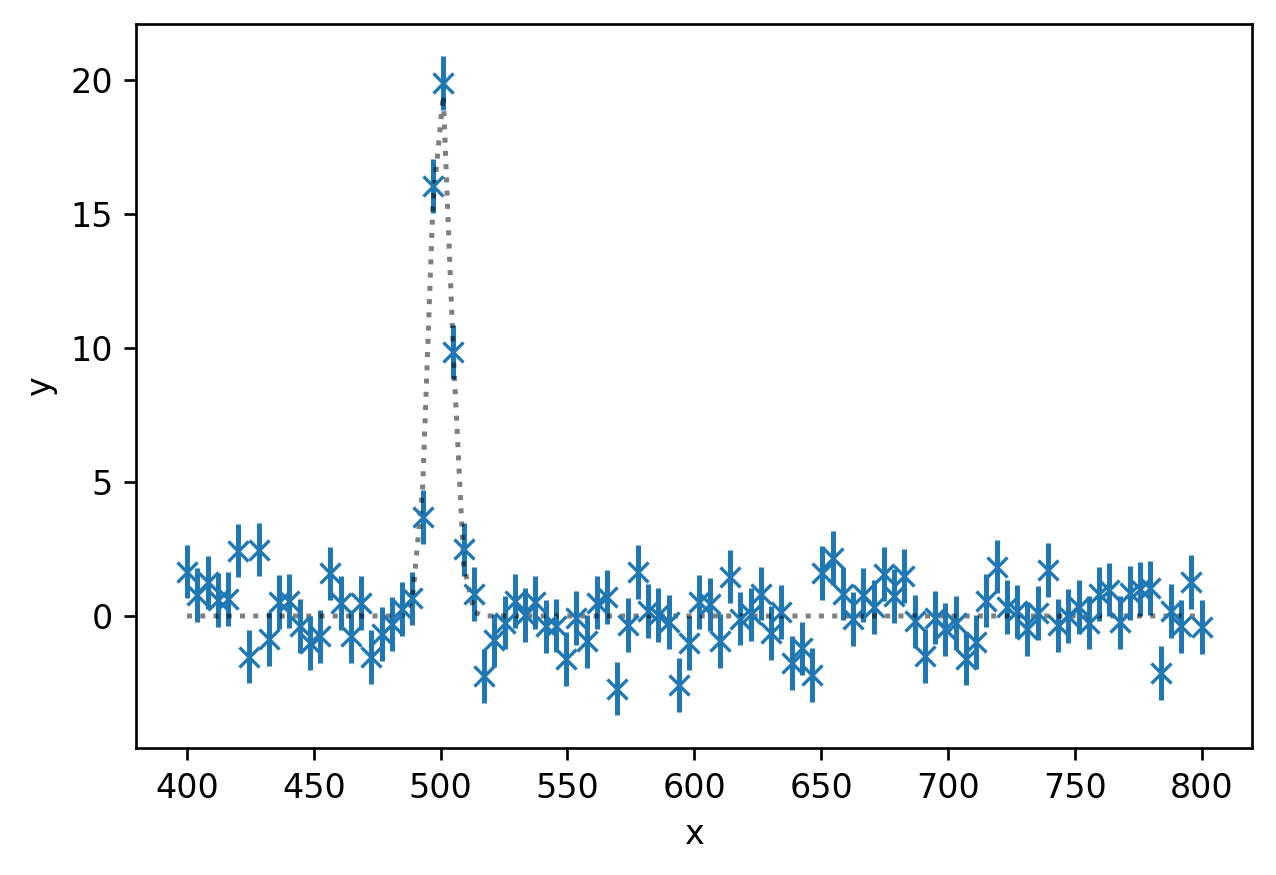

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 


plt.errorbar(x, y, yerr=yerr, ls=' ', marker='x')
plt.plot(x, 20 * np.exp(-0.5 * ((x-500)/4.2)**2), ls=':', alpha=0.5, color='k')
plt.xlabel('x')
plt.ylabel('y');

In [6]:
param_names = ['location', 'amplitude', 'width']

In [7]:
import scipy.stats

def my_prior_transform(cube): # The prior list for parameters
    params = cube.copy()

    # transform location parameter: uniform prior
    lo = 400
    hi = 800
    params[0] = cube[0] * (hi - lo) + lo

    # transform amplitude parameter: log-uniform prior
    lo = 0.1
    hi = 100
    params[1] = 10**(cube[1] * (np.log10(hi) - np.log10(lo)) + np.log10(lo))

    # More complex prior, you can use the ppf functions
    # from scipy.stats, such as scipy.stats.norm(mean, std).ppf

    # transform for width:
    # a log-normal centered at 1 +- 1dex
    params[2] = 10**scipy.stats.norm.ppf(cube[2], 0, 1)

    return params

In [8]:
from numpy import log

def my_likelihood(params):
    location, amplitude, width = params
    # compute intensity at every x position according to the model
    y_model = amplitude * np.exp(-0.5 * ((x - location)/width)**2)
    # compare model and data with gaussian likelihood:
    like = -0.5 * (((y_model - y)/yerr)**2).sum()
    return like

In [9]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)

In [15]:
result = sampler.run(show_status=False, viz_callback=None)
sampler.print_results()

[ultranest] Widening roots to 400 live points (have 400 already) ...
[ultranest] Explored until L=-6e+01  
[ultranest] Likelihood function evaluations: 20447
[ultranest]   logZ = -71.37 +- 0.176
[ultranest] Effective samples strategy satisfied (ESS = 1208.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.11 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

logZ = -71.414 +- 0.370
  single instance: logZ = -71.414 +- 0.183
  bootstrapped   : logZ = -71.371 +- 0.370
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    location            : 499.30│ ▁▁▁▁▁▁▁▂▂▂▃▃▅▆▇▇▇▇▆▆▅▆▄▃▂▂▁▁▁▁▁▁▁ ▁▁▁ │501.02    500.10 +- 0.21
    amplitude           : 16.94 │ ▁▁▁▁▁▁▁▁▁▂▃▄▅▄▅▆▇▇▇▇▆▅▃▃▃▂▂▁▁▁▁▁▁▁  ▁ │24.71     20.60 +- 0.92
    width               : 3.35  

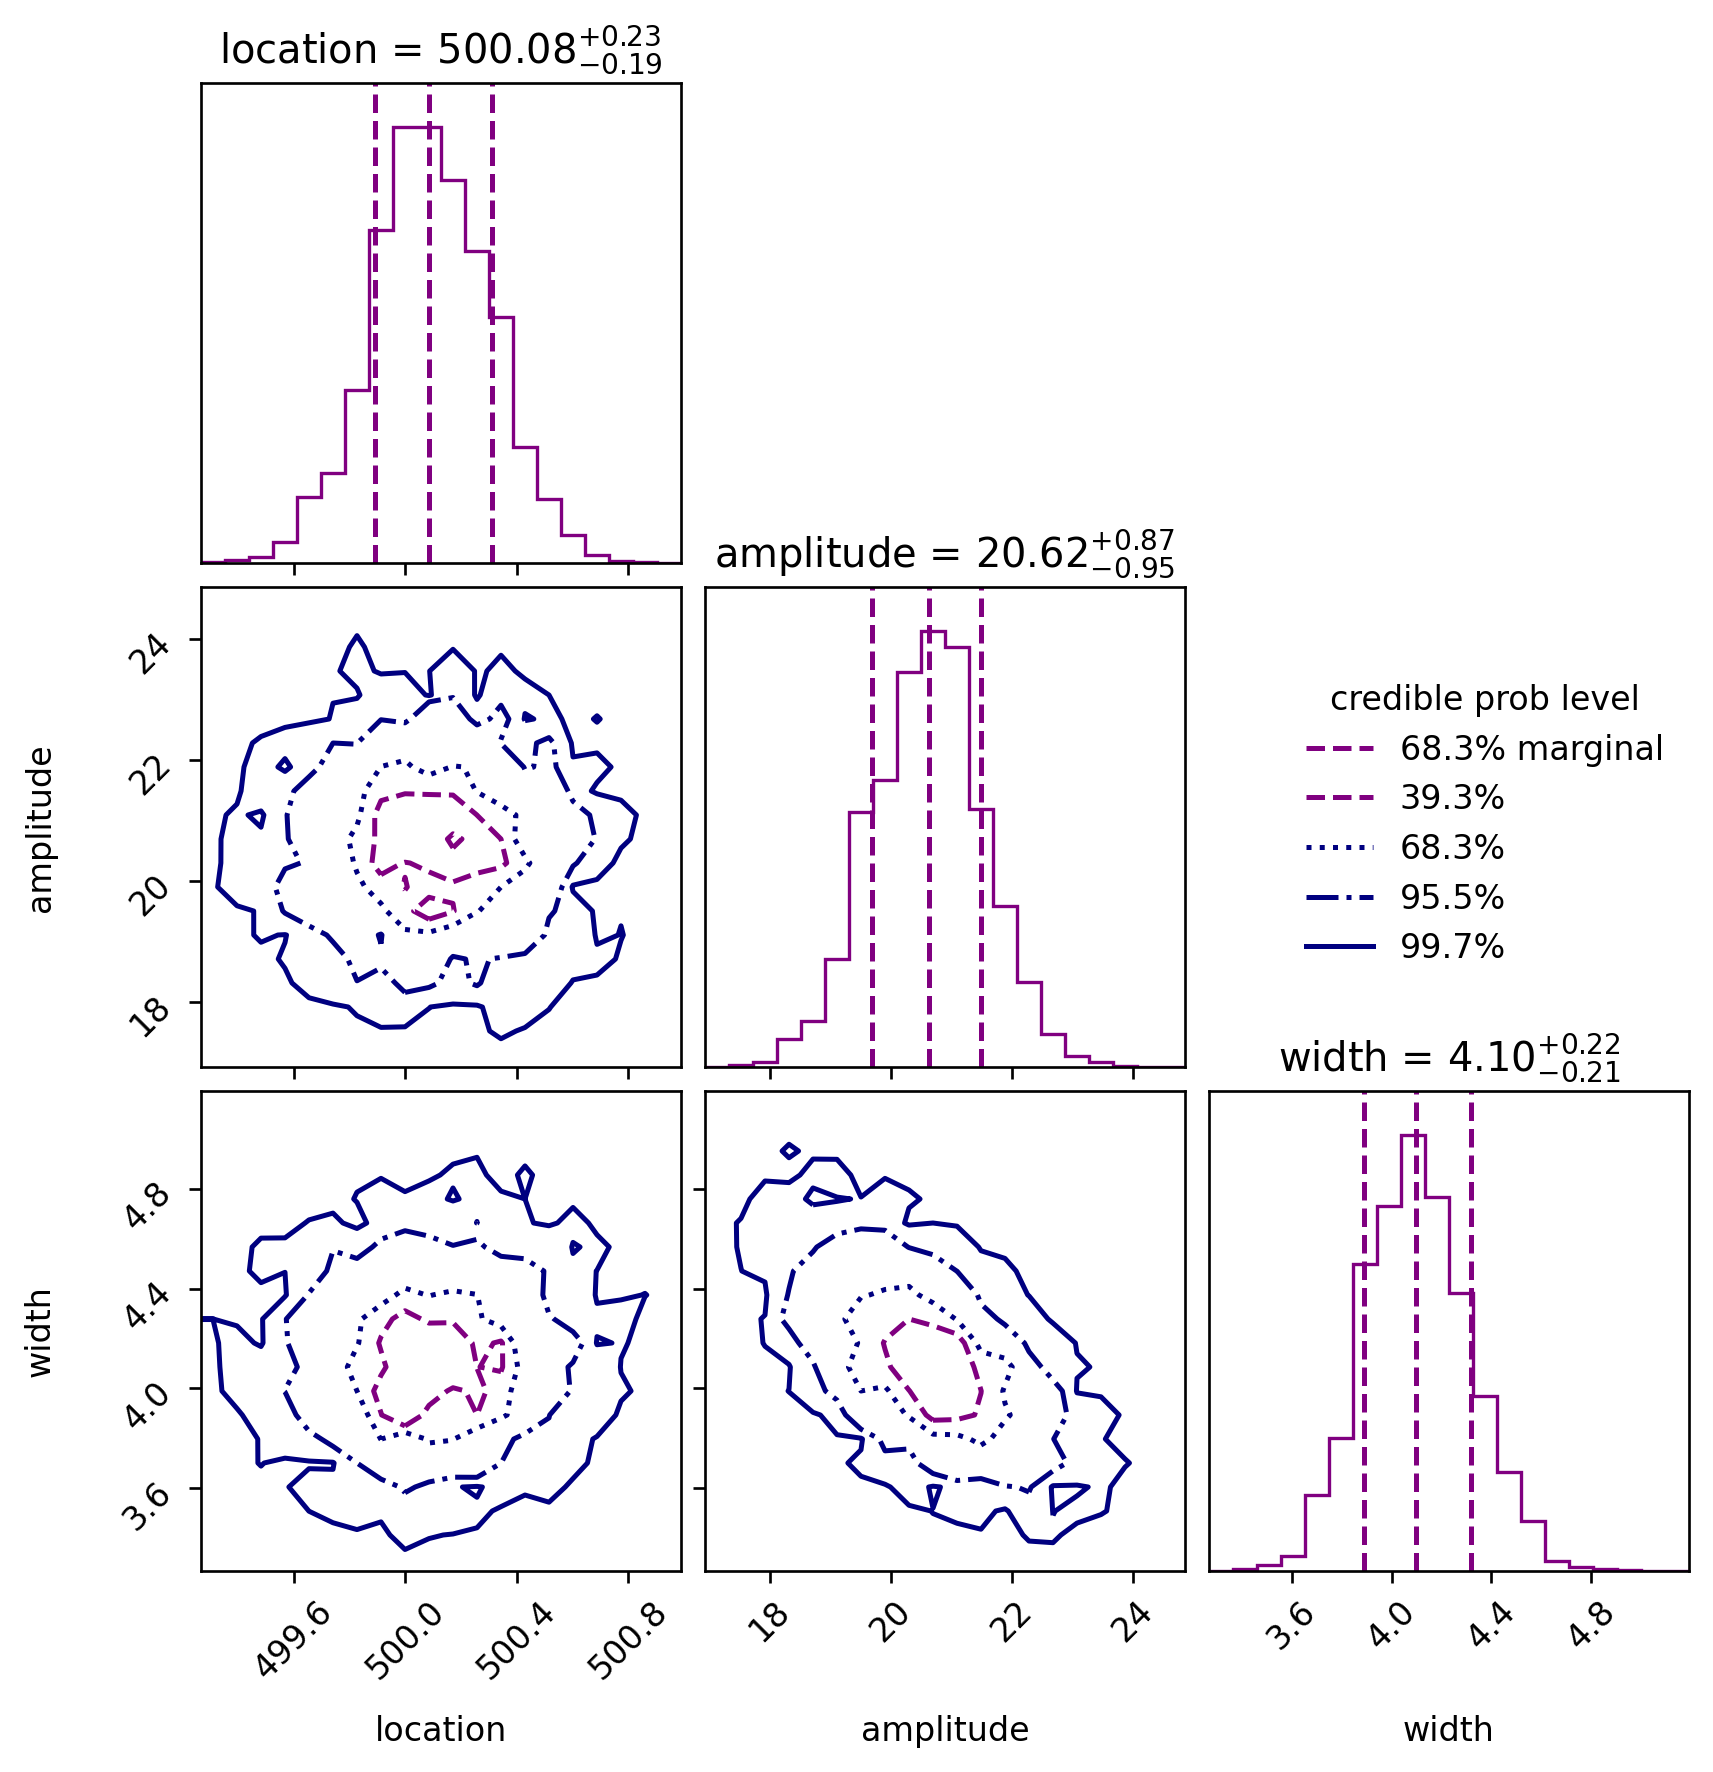

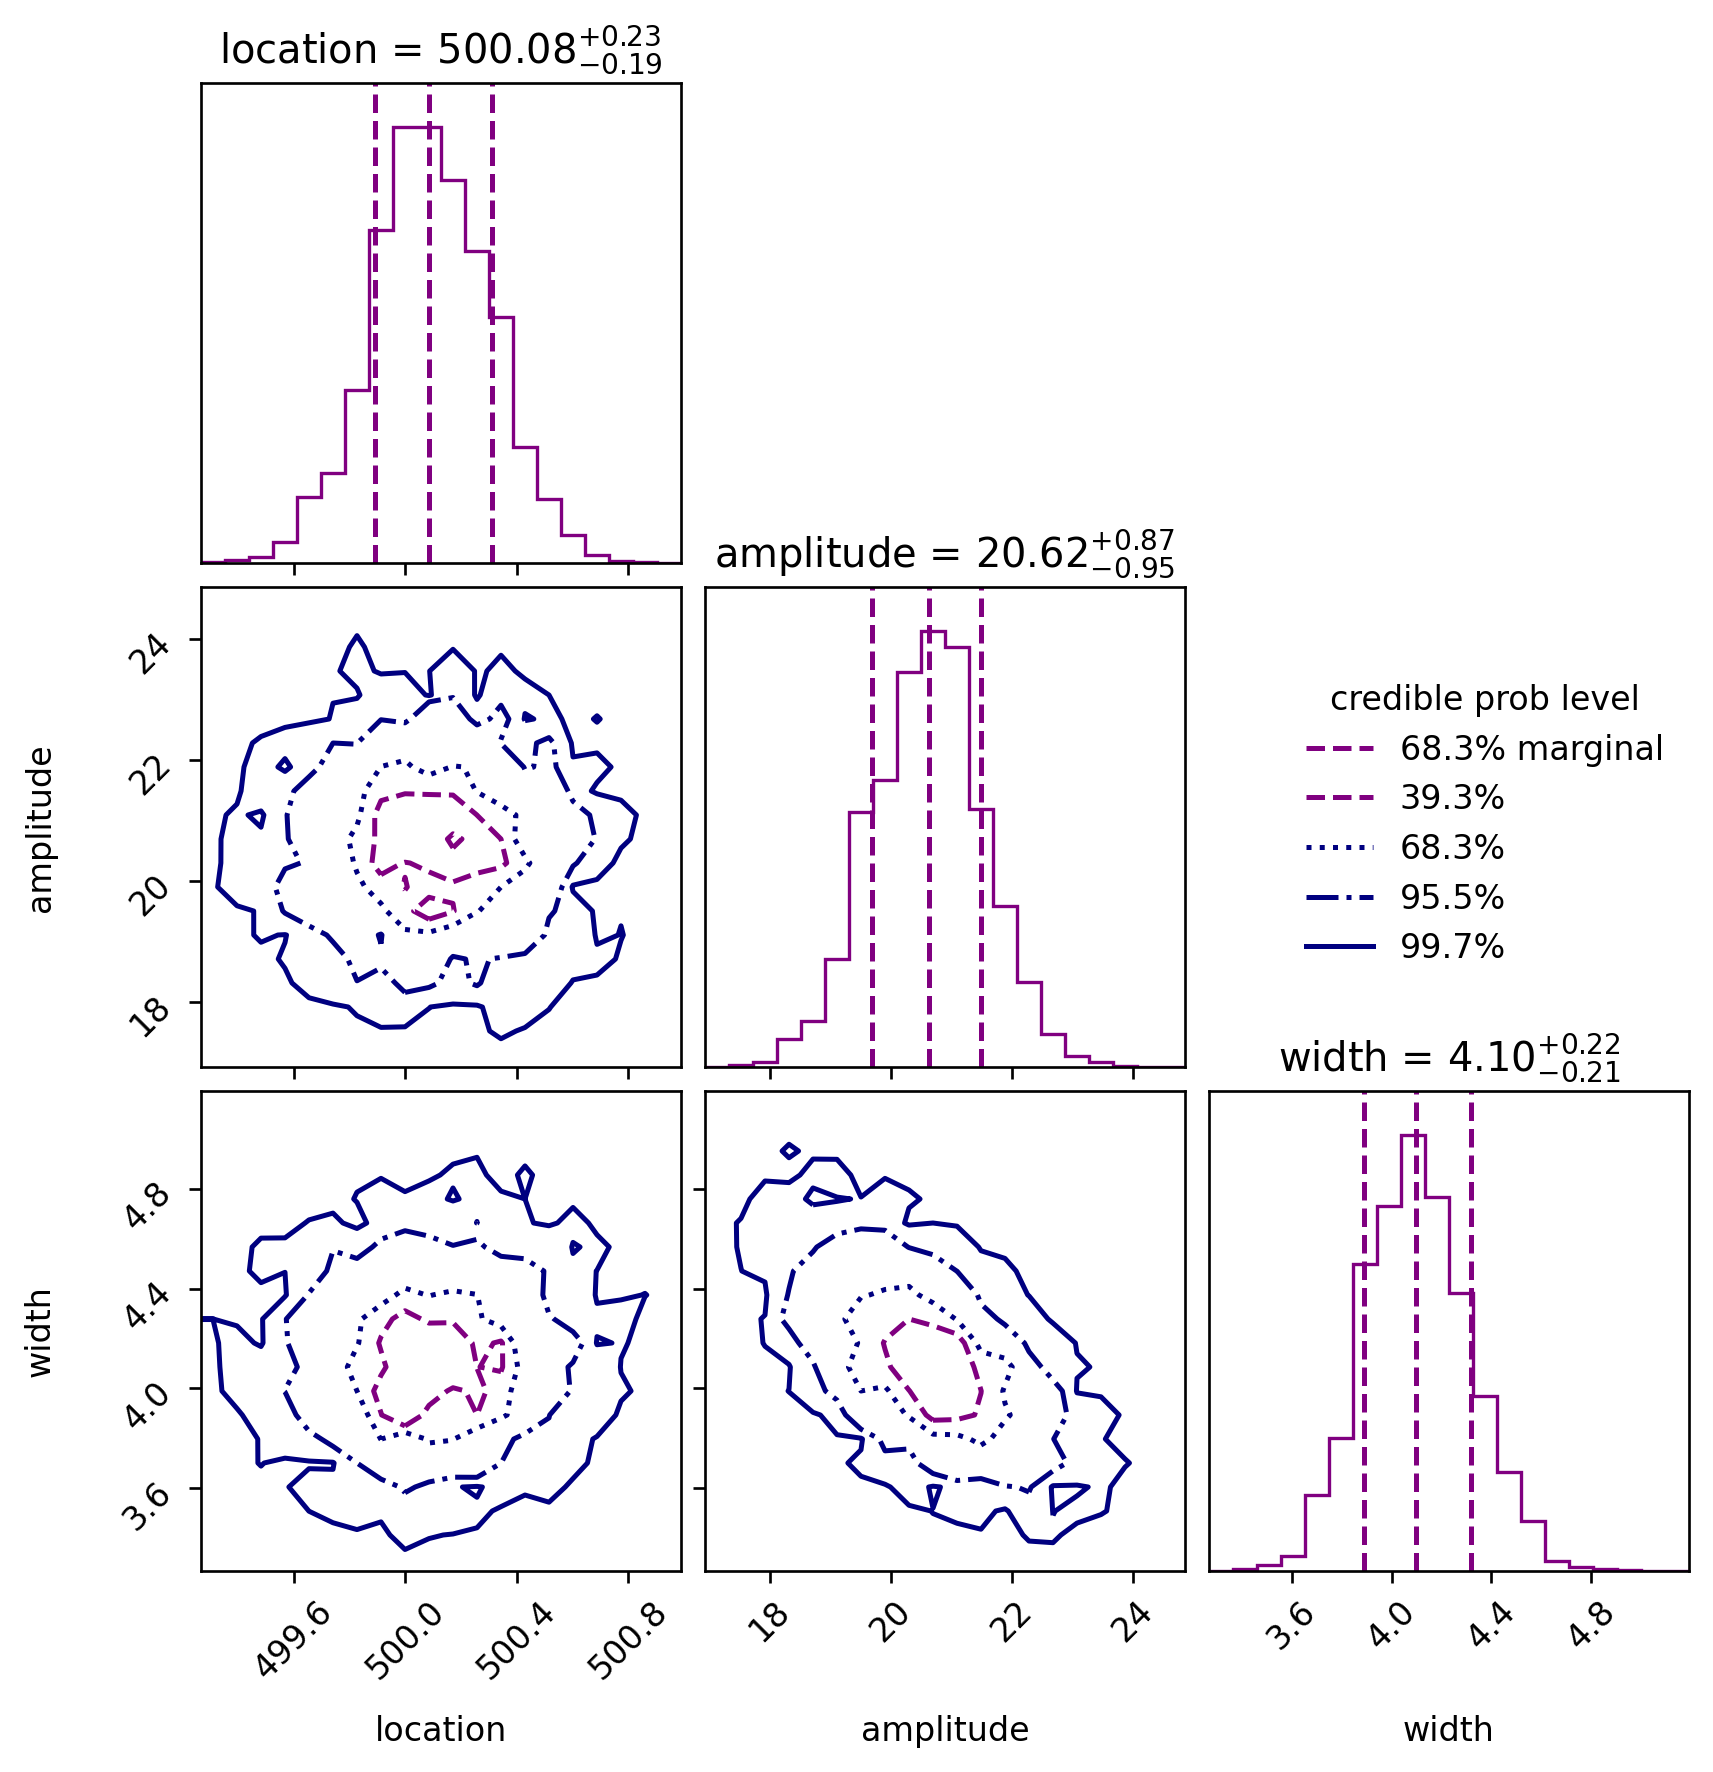

In [16]:
from ultranest.plot import cornerplot
cornerplot(result)

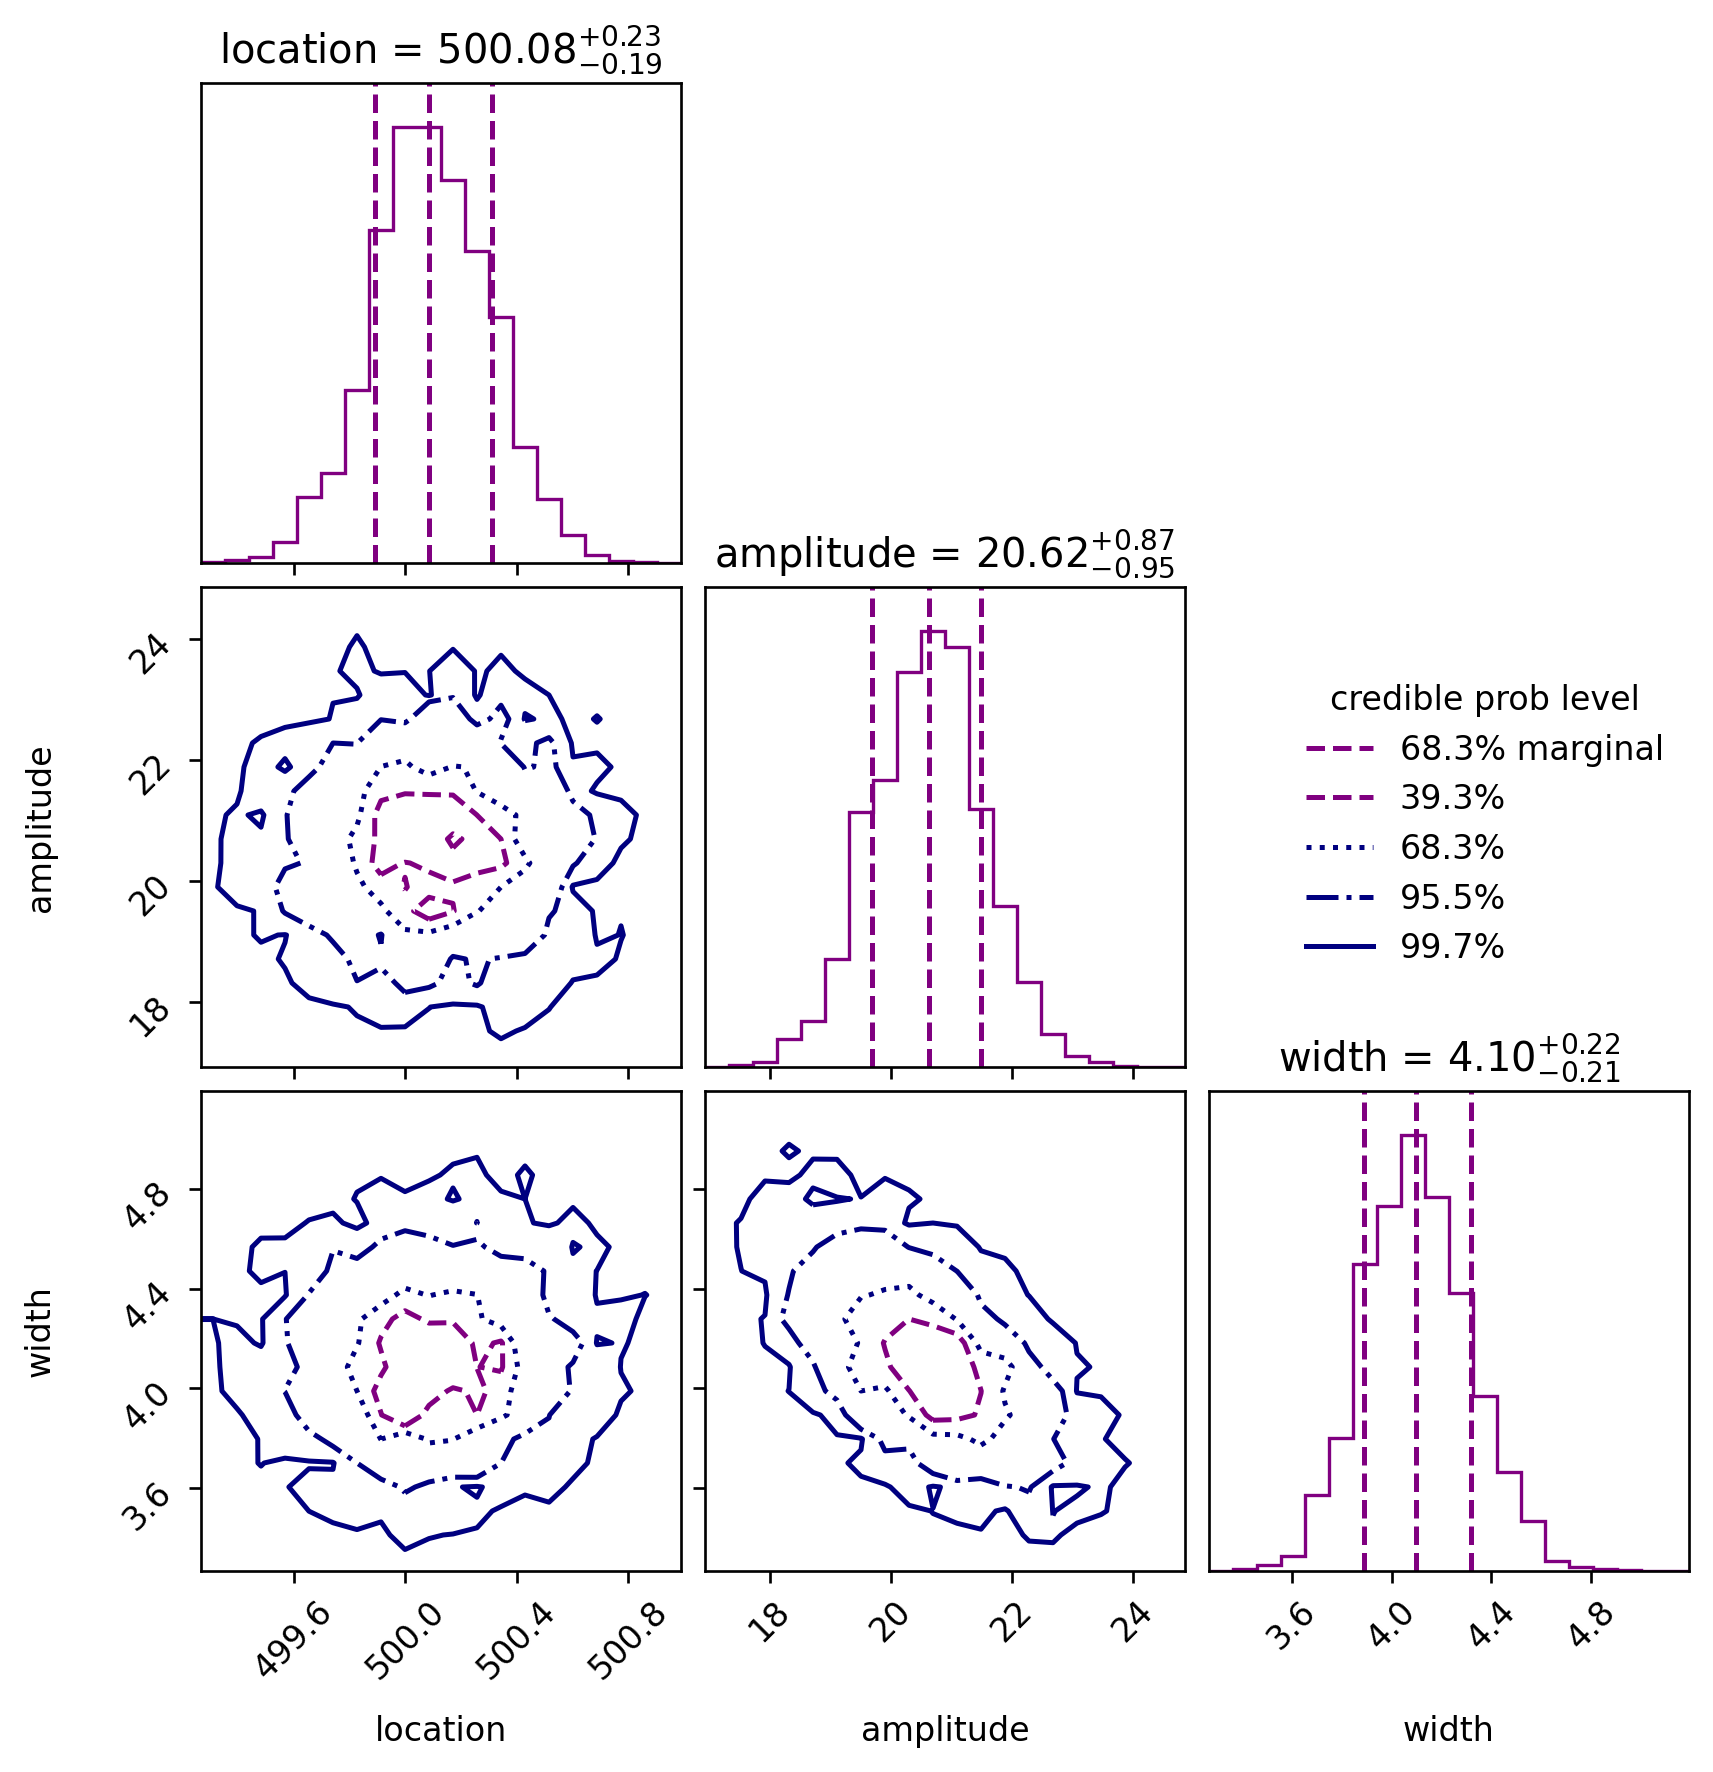

In [19]:
# sampler.plot_run()
# sampler.plot_trace()
sampler.plot_corner()